In [ ]:
%pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.3 MB/s eta 0:00:00


Délka: 1012 m,  uzlů: 10


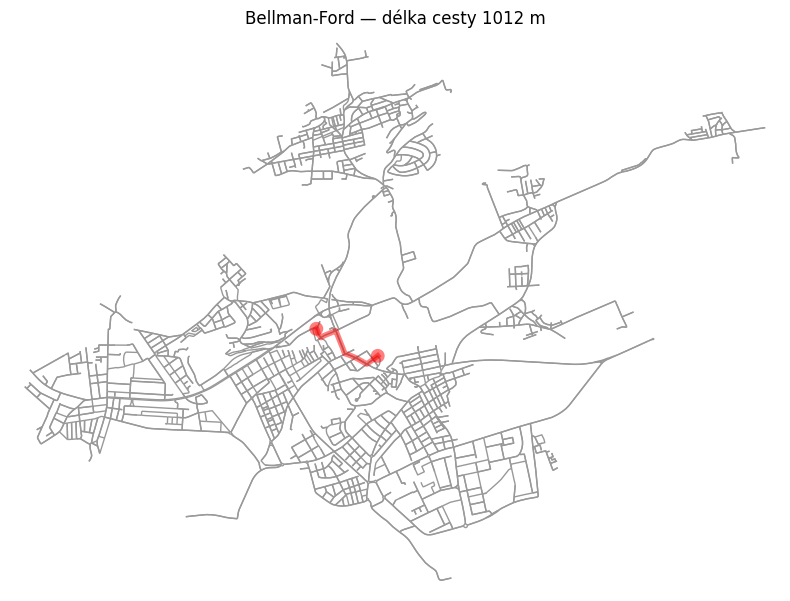

Cesta je dlouhá 1012.27 metrů.


/usr/local/lib/python3.12/dist-packages/osmnx/_validate.py:49: UserWarning: The attribute 'travel_time' is missing or null on some edges.
  _report_validation(is_valid, valid_msg, warn_msg, err_msg)


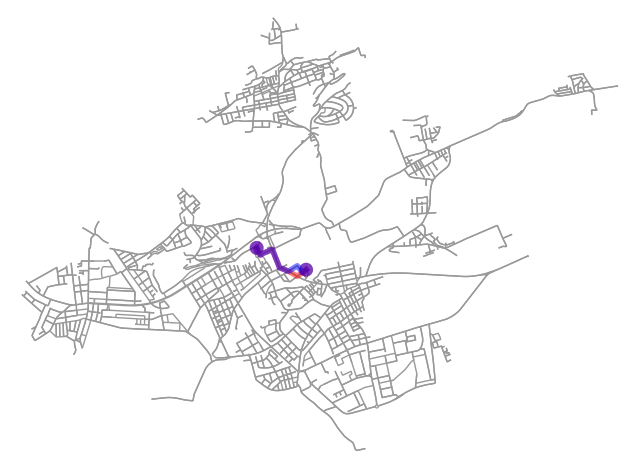

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

G = ox.graph_from_place(
    "Kladno, Czech Republic",
    network_type="drive",
    simplify=True
)

def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

start_gps = (50.1473, 14.1026)
cil_gps   = (50.1447, 14.1140)

start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white",
    show=False, close=False,
)
ax.set_title(f"Bellman-Ford — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford.png", dpi=150, bbox_inches="tight")
plt.show()

if nx.has_path(G, start, cil):
    try:
        cesta_delka = ox.shortest_path(G, start, cil, weight='length')
        delka_cesty = nx.shortest_path_length(G, start, cil, weight='length')
        print(f'Cesta je dlouhá {delka_cesty:.2f} metrů.')

        cesta_cas = None
        try:
            cesta_cas = ox.shortest_path(G, start, cil, weight='travel_time')
        except nx.NetworkXNoPath:
            print("Upozornění: Cesta pro 'travel_time' nebyla nalezena.")
        except Exception as e:
            print(f"Upozornění: Chyba pro 'travel_time': {e}")

        routes_to_plot = [cesta_delka]
        route_colors_to_plot = ["red"]
        route_linewidths_to_plot = [4]

        if cesta_cas is not None:
            routes_to_plot.append(cesta_cas)
            route_colors_to_plot.append("blue")
            route_linewidths_to_plot.append(4)

        ox.plot_graph_routes(
            G,
            routes=routes_to_plot,
            route_colors=route_colors_to_plot,
            route_linewidths=route_linewidths_to_plot,
            node_size=0,
            bgcolor="white",
        )

    except nx.NetworkXNoPath:
        print("Chyba: Nepodařilo se najít cestu.")
    except Exception as e:
        print(f"Neočekávaná chyba: {e}")
else:
    print("Chyba: Uzly nejsou propojené.")